Add all the tools


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

In [4]:
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("seaborn",sns.__version__)
print("sklearn",sklearn.__version__)

numpy 2.2.2
pandas 2.2.3
seaborn 0.13.2
sklearn 1.6.1


Load the kaggle dataset

In [10]:
house_price_dataset = pd.read_csv("kolkata_house_prices_with_floors.csv")

print the read data


In [11]:
print(house_price_dataset)

      Area (sqft)  Living Area (sqft)  Bedrooms  Bathrooms  Garage  \
0            3102                2470         1          3       0   
1            2419                1458         5          3       0   
2            1317                1016         1          2       0   
3            3382                2509         4          3       0   
4            1450                1288         5          2       1   
...           ...                 ...       ...        ...     ...   
9995         2933                2462         5          2       1   
9996         2231                1721         2          3       1   
9997         2959                2174         4          3       0   
9998         2956                2360         1          2       1   
9999         1374                 839         2          2       0   

      Age of House (years)  Location Score  Price (INR)  Number of Floors  
0                       22               5     14669000                 3  
1      

loading the dataset to a pandas dataframe


In [12]:
house_price_dataset = pd.DataFrame(house_price_dataset)

In [13]:
house_price_dataframe =  house_price_dataset.iloc[:,[0,1,8,2,3,4,5,6,7]]

In [14]:
house_price_dataframe.head()

,Area (sqft),Living Area (sqft),Number of Floors,Bedrooms,Bathrooms,Garage,Age of House (years),Location Score,Price (INR)
0,3102,2470,3,1,3,0,22,5,14669000
1,2419,1458,4,5,3,0,3,5,13175500
2,1317,1016,1,1,2,0,27,9,6536500
3,3382,2509,3,4,3,0,11,4,16999000
4,1450,1288,3,5,2,1,14,5,8545000


checking the number of rows and coloumn in the data frame

In [15]:
house_price_dataframe.shape

(10000, 9)

check  missing value in the data set

In [17]:
house_price_dataframe.isnull().sum()

Area (sqft)             0
Living Area (sqft)      0
Number of Floors        0
Bedrooms                0
Bathrooms               0
Garage                  0
Age of House (years)    0
Location Score          0
Price (INR)             0
dtype: int64

now find the statistical measures of the dataset

In [16]:
house_price_dataframe.describe()

,Area (sqft),Living Area (sqft),Number of Floors,Bedrooms,Bathrooms,Garage,Age of House (years),Location Score,Price (INR)
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,2044.362200,1529.453700,2.49430,3.000300,1.993200,0.489500,14.727000,5.548600,1.055467e+07
std,835.129693,652.045285,1.12138,1.421725,0.818426,0.499915,8.691641,2.872188,3.786750e+06
min,600.000000,367.000000,1.00000,1.000000,1.000000,0.000000,0.000000,1.000000,2.964500e+06
25%,1323.000000,974.000000,1.00000,2.000000,1.000000,0.000000,7.000000,3.000000,7.338375e+06
50%,2039.000000,1510.000000,2.00000,3.000000,2.000000,0.000000,15.000000,6.000000,1.050275e+07
75%,2761.000000,2036.000000,4.00000,4.000000,3.000000,1.000000,22.000000,8.000000,1.377525e+07
max,3499.000000,3144.000000,4.00000,5.000000,3.000000,1.000000,29.000000,10.000000,1.823400e+07


now drop the unnecessary vaeriable column form the dataset

In [ ]:
# new_house_price_dataframe = house_price_dataframe.drop(['id','Date','living area','waterfront present','number of views','condition of the house','grade of the house','Area of the house(excluding basement)','Area of the basement','Built Year','Renovation Year','Postal Code','Lattitude','Longitude','living_area_renov','lot_area_renov','Number of schools nearby','Distance from the airport'], axis=1)

now find the correlation between the data after droping the unnecessary data.


correlation are two type

1.+ve correlation(if one var increase than other var will also increase)

2.-ve correlation(if one var decrease than other var will also decrease)


In [19]:
correlation = house_price_dataframe.corr()

now we will constract a heatmap for the understanding the correlation

<Axes: >

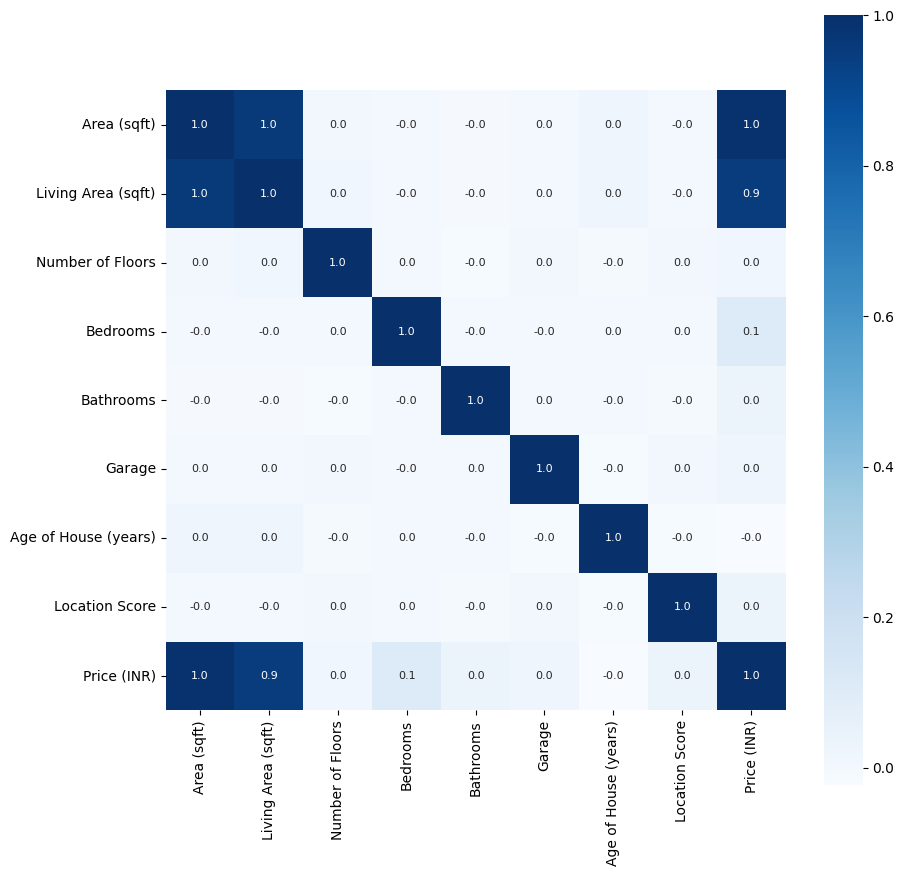

In [20]:
plt.figure(figsize = (10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

now we will split the data and the target(price) for the training is

In [27]:
X = house_price_dataframe.drop(columns='Price (INR)', axis=1)
Y = house_price_dataframe['Price (INR)']

In [28]:
print(X)
print(Y)

      Area (sqft)  Living Area (sqft)  Number of Floors  Bedrooms  Bathrooms  \
0            3102                2470                 3         1          3   
1            2419                1458                 4         5          3   
2            1317                1016                 1         1          2   
3            3382                2509                 3         4          3   
4            1450                1288                 3         5          2   
...           ...                 ...               ...       ...        ...   
9995         2933                2462                 4         5          2   
9996         2231                1721                 3         2          3   
9997         2959                2174                 2         4          3   
9998         2956                2360                 2         1          2   
9999         1374                 839                 1         2          2   

      Garage  Age of House (years)  Loc

splitting the data into training data test data

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [30]:
print(X.shape,X_train.shape,X_test.shape)

(10000, 8) (8000, 8) (2000, 8)


now we will doing the model training

we are using the GreadiantBoostingRegressor model

In [31]:
model = GradientBoostingRegressor()

traning the model with X_train(X_train consist the data about the area and the floor number)

In [32]:
model.fit(X_train, Y_train)

GradientBoostingRegressor()

Evaluation of the model after training

prediction the training data

In [33]:
training_data_prediction = model.predict(X_train)

In [34]:
print(training_data_prediction)

[16254627.59250066  5283068.23087215 15967578.86597438 ...
  7157299.11603248 15060805.38175436 17169258.89762856]


checking the error value of the model

for this purpose we are using the R squared error checking method

now we are going to find the Mean absolute Error

---




In [35]:
score_1 = metrics.r2_score(Y_train, training_data_prediction)
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)
print("R squared error : ", score_1)
'''If the R squared error is very small means that the accuracy of the model is very high '''
print('Mean Absolute Error : ', score_2)

R squared error :  0.9996877668665513
Mean Absolute Error :  53229.718967863795


In [36]:
test_data_prediction = model.predict(X_test)
score_3= metrics.r2_score(Y_test, test_data_prediction)
score_4 = metrics.mean_absolute_error(Y_test, test_data_prediction)
print("R squared error : ", score_3)
print('Mean Absolute Error : ', score_4)

R squared error :  0.9995618296337201
Mean Absolute Error :  62407.091780267736


visualizing the actual Prices and predicted prices

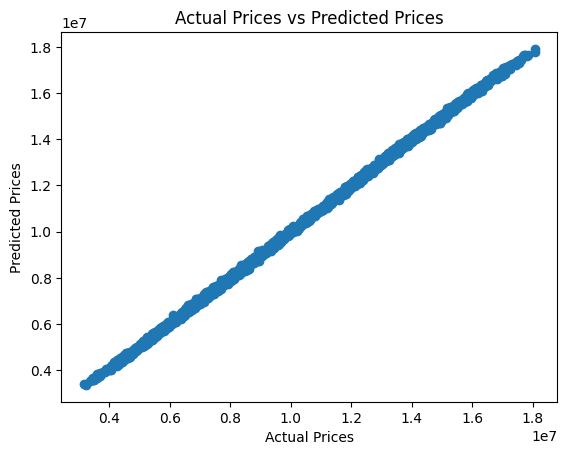

In [37]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [39]:
predict_value = [[2000,1600,2,4,3,1,0,8]]
value_of_p = model.predict(predict_value)
print(f"predicted price:{value_of_p}")

predicted price:[11209881.43196502]


c:\Users\AQIB\anaconda3\envs\newenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [40]:
import pickle

In [41]:
with open('model.pkl','wb') as files:
  pickle.dump(model,files)